# Phase 2: Exploratory Data Analysis (EDA)

Objective:
To analyze the statistical and temporal properties of stock price data 
before applying machine learning models.

This phase includes:
- Price trend visualization
- Daily return computation
- Return distribution analysis
- Volatility clustering examination

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Reliance dataset
df = pd.read_csv("../data/raw/RELIANCE.NS.csv", index_col=0)

df.head()

,Close,High,Low,Open,Volume
Price,,,,,
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,NaN,NaN,NaN,NaN,NaN
2021-03-02,954.9262084960938,965.8085514456496,947.2632505723379,962.1811437745009,17150760
2021-03-03,998.5009765625,1006.572077071357,955.4703590572257,961.750393670414,31924461
2021-03-04,986.5984497070312,992.9918242849485,978.3686732860034,988.4801874020635,21435754


In [6]:
df = pd.read_csv("../data/raw/RELIANCE.NS.csv")

# Drop rows where first column contains non-date values
df = df[df.iloc[:,0] != "Ticker"]

# Rename first column to Date
df.rename(columns={df.columns[0]: "Date"}, inplace=True)

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop any rows where Date conversion failed
df = df.dropna(subset=["Date"])

# Set Date as index
df.set_index("Date", inplace=True)

# Ensure Close is numeric
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_2768\3843630939.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


,Close,High,Low,Open,Volume
Date,,,,,
2021-03-02,954.926208,965.8085514456496,947.2632505723379,962.1811437745009,17150760
2021-03-03,998.500977,1006.572077071357,955.4703590572257,961.750393670414,31924461
2021-03-04,986.598450,992.9918242849485,978.3686732860034,988.4801874020635,21435754
2021-03-05,987.890686,1002.9673152550806,976.260181188279,977.5978286714029,25511666
2021-03-08,993.513306,1012.0132716669716,983.039044773577,983.2657240329895,19506841


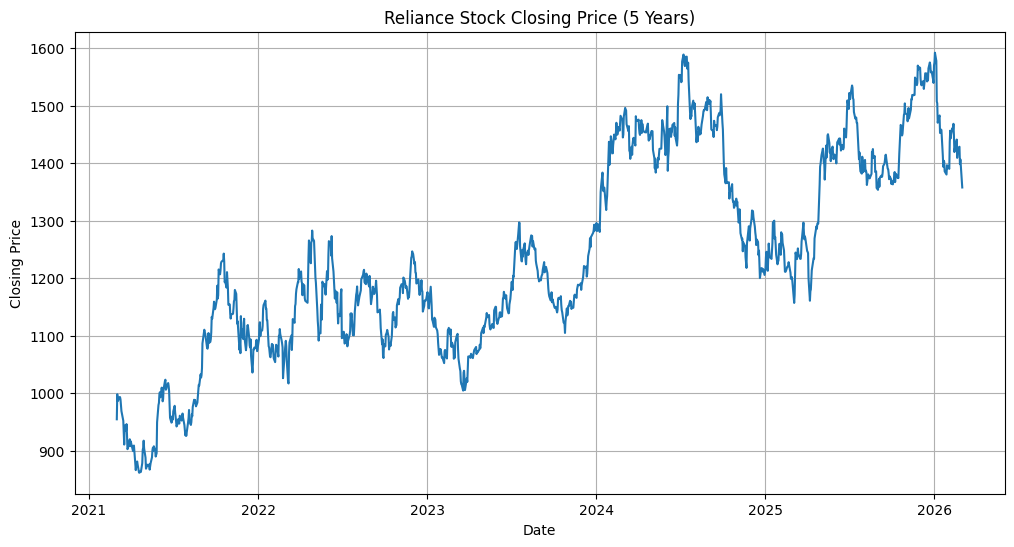

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"])
plt.title("Reliance Stock Closing Price (5 Years)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

## Observations

- The stock exhibits long-term trend behavior.
- Periods of sharp decline are visible, indicating market corrections.
- The price movement is non-linear and time-dependent.

This confirms that stock prices follow a time-series structure
and require temporal modeling rather than random sampling.

In [8]:
# Compute daily percentage return
df["Daily_Return"] = df["Close"].pct_change()

df.head()

,Close,High,Low,Open,Volume,Daily_Return
Date,,,,,,
2021-03-02,954.926208,965.8085514456496,947.2632505723379,962.1811437745009,17150760,NaN
2021-03-03,998.500977,1006.572077071357,955.4703590572257,961.750393670414,31924461,0.045632
2021-03-04,986.598450,992.9918242849485,978.3686732860034,988.4801874020635,21435754,-0.011920
2021-03-05,987.890686,1002.9673152550806,976.260181188279,977.5978286714029,25511666,0.001310
2021-03-08,993.513306,1012.0132716669716,983.039044773577,983.2657240329895,19506841,0.005692


In [9]:
df = df.dropna()

df.head()

,Close,High,Low,Open,Volume,Daily_Return
Date,,,,,,
2021-03-03,998.500977,1006.572077071357,955.4703590572257,961.750393670414,31924461,0.045632
2021-03-04,986.598450,992.9918242849485,978.3686732860034,988.4801874020635,21435754,-0.011920
2021-03-05,987.890686,1002.9673152550806,976.260181188279,977.5978286714029,25511666,0.001310
2021-03-08,993.513306,1012.0132716669716,983.039044773577,983.2657240329895,19506841,0.005692
2021-03-09,993.490479,1003.8060628939456,973.3355160603489,997.548696502313,15154484,-0.000023


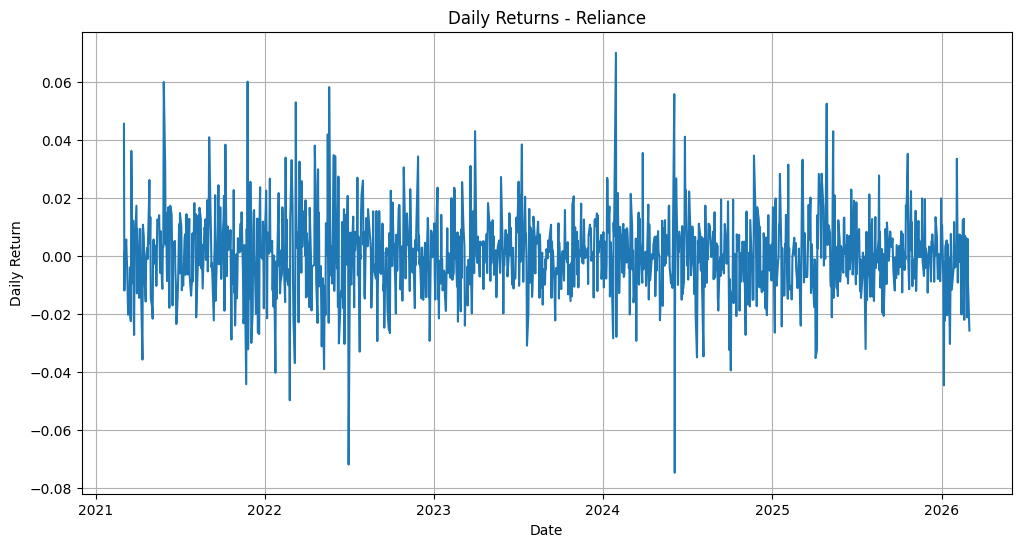

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Daily_Return"])
plt.title("Daily Returns - Reliance")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

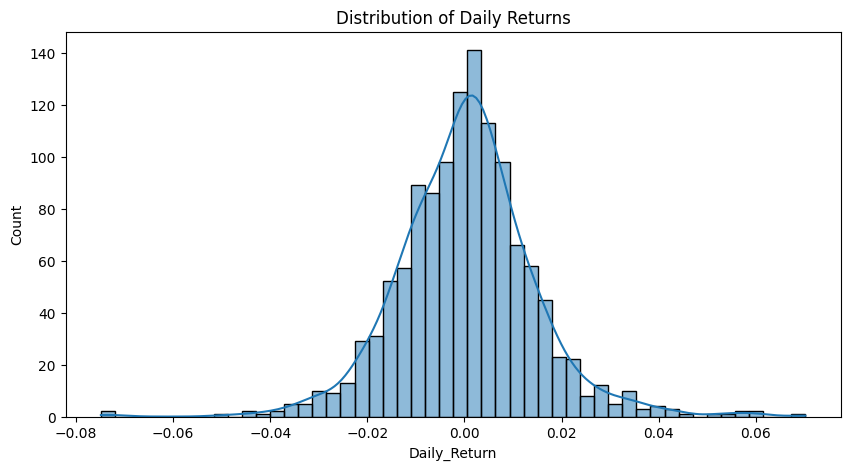

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df["Daily_Return"], bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

In [12]:
# 20-day rolling volatility
df["Rolling_Volatility"] = df["Daily_Return"].rolling(window=20).std()

df.head()

,Close,High,Low,Open,Volume,Daily_Return,Rolling_Volatility
Date,,,,,,,
2021-03-03,998.500977,1006.572077071357,955.4703590572257,961.750393670414,31924461,0.045632,NaN
2021-03-04,986.598450,992.9918242849485,978.3686732860034,988.4801874020635,21435754,-0.011920,NaN
2021-03-05,987.890686,1002.9673152550806,976.260181188279,977.5978286714029,25511666,0.001310,NaN
2021-03-08,993.513306,1012.0132716669716,983.039044773577,983.2657240329895,19506841,0.005692,NaN
2021-03-09,993.490479,1003.8060628939456,973.3355160603489,997.548696502313,15154484,-0.000023,NaN


In [13]:
df = df.dropna()
df.head()

,Close,High,Low,Open,Volume,Daily_Return,Rolling_Volatility
Date,,,,,,,
2021-04-01,916.769958,920.465429845356,908.2907755247039,915.0242884490825,11723312,0.009361,0.019212
2021-04-05,903.507141,918.1982951252521,889.677488179083,918.1756272004715,14875099,-0.014467,0.015787
2021-04-06,899.743652,909.1070043382359,892.8061280725167,908.6762538058488,14009194,-0.004165,0.015699
2021-04-07,908.154846,928.1285275370888,903.8246126194147,906.8625944881165,24266353,0.009348,0.015956
2021-04-08,909.288330,916.8379481306634,903.6884533297169,911.850225266319,15369188,0.001248,0.015843


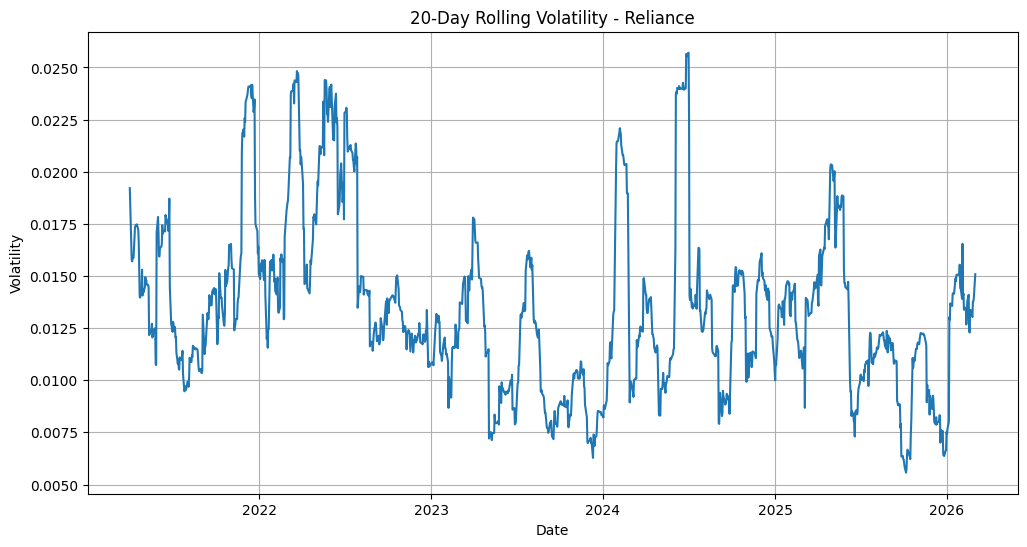

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Rolling_Volatility"])
plt.title("20-Day Rolling Volatility - Reliance")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

## Volatility Analysis

- Volatility is not constant over time.
- High-volatility periods cluster together.
- This confirms heteroskedastic behavior in financial time-series.

This justifies the need for dynamic risk modeling.

In [15]:
print("Mean Daily Return:", df["Daily_Return"].mean())
print("Standard Deviation:", df["Daily_Return"].std())
print("Skewness:", df["Daily_Return"].skew())
print("Kurtosis:", df["Daily_Return"].kurt())

Mean Daily Return: 0.0004285829964287087
Standard Deviation: 0.014015777952340994
Skewness: 0.142577326056354
Kurtosis: 2.9298642279615263


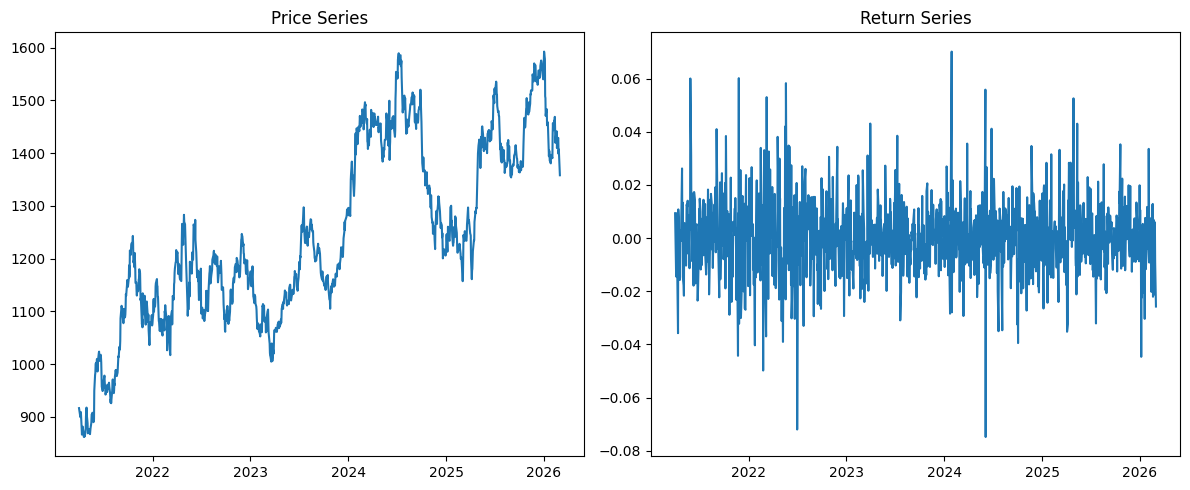

In [16]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(df.index, df["Close"])
plt.title("Price Series")

plt.subplot(1,2,2)
plt.plot(df.index, df["Daily_Return"])
plt.title("Return Series")

plt.tight_layout()
plt.show()

## Stationarity Insight

- Stock prices exhibit non-stationary behavior due to long-term trends.
- Daily returns fluctuate around a relatively stable mean.
- Returns are therefore more suitable for machine learning modeling.

This confirms that feature engineering should be based on returns 
rather than raw prices.